# An introduction to RAG and embbedings

In this exercise, I explore the use of Retrieval Augmented Generation (RAG) and embeddings. The basic idea behind RAG is to improve the generation from LLM by injecting additional information from an external Knowledge database to improve results and add more relevant or newer information. This can substantially improve the accuracy of the LLM assistant and/or provide newer information that was not available during pre-training or fine-tuning.

# Tools and vector database

Using RAG requires storing information in a vector database. A vector database/store is where documents are stored by projecting text in an embedding. This allows the conversion of text into a vector space representation that can be easily queried by the LLM in vector format. Relevant information is returned by looking at documents that are in the neighborhood of the queried documents/information. This information is then injected into the prompt to enrich the generation of the LLM response.

In this exercise, we will use the langchain framework and tool to implement RAG.

# Data: the knowledge base

As an example, I will a knowledge base made up of 50+ more scientific and grey papers published in AI and Deep Learning. Topics covered in the database overlap my interest and  what I consider to be important papers in the field. Most of the papers fall into:

- weather and AI
- NLP and LLM
- computer vision and AI
- graph and AI
- CBI and AI
- Deep Learning


## Interesting links:

- prompting:

https://cloud.google.com/discover/what-is-prompt-engineering
https://medium.com/@hey.musli/the-anatomy-of-an-effective-chatgpt-prompt-e17f95a230ef

- embeddings:

https://huggingface.co/blog/getting-started-with-embeddings

https://medium.com/@rahultiwari065/unlocking-the-power-of-sentence-embeddings-with-all-minilm-l6-v2-7d6589a5f0aa

https://huggingface.co/spaces/mteb/leaderboard




- RAG:

https://medium.com/@tejpal.abhyuday/retrieval-augmented-generation-rag-from-basics-to-advanced-a2b068fd576c

https://github.com/ed-donner/llm_engineering/blob/main/week5/day2.ipynb

https://jorgepit-14189.medium.com/get-started-with-chroma-db-and-retrieval-models-using-langchain-87784ffaa918



# Set up environment and load libraries

- load libraries
- install packages and tools
- authenticate to google drive and gcp account

General purpose libraries and packages

In [1]:
!pip list

Package                                  Version
---------------------------------------- -------------------
absl-py                                  1.4.0
accelerate                               1.12.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.3
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                         

In [2]:
#pip install "huggingface-hub>=0.33.4,<1.0.0"
#!pip install huggingface-hub<2.0,>=1.3.0

In [3]:
!pip install openai
!pip install langchain-openai
!pip install langchain-chroma
!pip install langchain-huggingface
!pip install langchain-community
!pip install langchain-text-splitters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.5/21.5 MB 34.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 80.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 23.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.6/132.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.4/66.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.0/220.0 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/6

For pdf text extraction

In [4]:
!pip install pdfminer.six
!pip install tiktoken

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 35.2 MB/s eta 0:00:00


In [5]:
#!pip install --upgrade huggingface_hub sentence-transformers


In [6]:
#pip uninstall -y huggingface_hub sentence-transformers transformers

In [7]:
import langchain
langchain.__version__

'1.2.10'

In [8]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib import colors
import matplotlib.patches as mpatches
import seaborn as sns

import numpy as np
import subprocess
import pandas as pd
import os, glob
import zipfile

from pathlib import Path

sns.set_style('darkgrid')
#pd.set_option('display.max_colwidth', None)
!apt install unzip
import urllib
import re
import math
from datetime import datetime
from copy import deepcopy
from numpy.core.multiarray import datetime_as_string
import os
import numpy.ma as ma

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unzip is already the newest version (6.0-26ubuntu3.2).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.


/tmp/ipython-input-975698043.py:25: DeprecationWarning: numpy.core.multiarray is deprecated and has been renamed to numpy._core.multiarray. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.multiarray.datetime_as_string.
  from numpy.core.multiarray import datetime_as_string


In [9]:
!pip install langchain-openai
!pip install langchain-chroma


In [10]:
import os
import glob
import tiktoken
import numpy as np
from dotenv import load_dotenv
from langchain_openai import OpenAIEmbeddings
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import DirectoryLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sklearn.manifold import TSNE
import plotly.graph_objects as go

In [11]:
#Used in defining functions
from typing import List, Tuple, Dict, Any
from pandas.core.arrays import boolean

In [12]:
import openai

In [13]:
!sudo apt install tree
!pip install tree
!pip install python-dotenv

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 2 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 0s (144 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package tree.
(Reading database ... 117540 files and directories currently installe

# Configuration and env variables

In [14]:
#GCP account authentification
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

Authenticated


In [15]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [16]:
!pip install python-dotenv

In [17]:
from google.colab import files
uploaded = files.upload()

Saving .env to .env


Let's upload .env

In [18]:
import dotenv
dotenv.load_dotenv('./.env')

True

# Functions
In the next part of the script, we declare all the functions used in the sripts.  It is good practice to place functions at the beginning of a script or in an external source file. Here are the 13 functions used:

In [19]:
def create_dir_and_check_existence(path: str) -> str:
  '''
  Create a new directory

  :param path: path to the directory
  :return: path to the directory
  '''

  try:
    os.makedirs(path)
  except:
    print ("directory already exists")
  return path



# Parameters and Arguments

It is good practice to set all parameters and input arguments at the beginning of the script. This allows for better control and can make modifications of the scripts for other applications easier. Some arguments relate to path directories, input files and general parameters for use in the analyses (e.g. proportion of hold out).


In [20]:

#ARG 1
in_dir = '/content/gdrive/MyDrive/Colab Notebooks/Large-Language-Models-applications/llm-rag-embeddings/data/'
#ARG 2
out_dir = "/content/gdrive/MyDrive/Colab Notebooks/Large-Language-Models-applications/llm-rag-embeddings"
#ARGS 3:
create_out_dir=True #create a new ouput dir if TRUE
#ARG 4
#out_suffix = "202410313" #output suffix for the files and ouptut folder
out_suffix = "20260211" #output suffix for the files and ouptut folder

random_seed=105 # set seed for reproducibility of results

llm_model_name = "gpt-3.5-turbo"
#llm_model_name = "gpt-4o-mini"
embedding_model_name = "sentence-transformers/all-MiniLM-L6-v2" #need access to hugging face and sentence-transformer
embedding_model_name = "text-embedding-3-small"
embedding_origin = 'openAI'

In [21]:
#set up the working directory
#Create output directory

if create_out_dir==True:
    out_dir_new = "output_data_"+out_suffix
    out_dir = os.path.join(out_dir,"outputs",out_dir_new)
    create_dir_and_check_existence(out_dir)
    os.chdir(out_dir)        #set working directory
else:
    os.chdir(out_dir) #use working dir defined earlier


directory already exists


In [22]:
print(out_dir)

/content/gdrive/MyDrive/Colab Notebooks/Large-Language-Models-applications/llm-rag-embeddings/outputs/output_data_20260211


#1.Embedding and RAG example

We will first show and example of simple RAG application using mock up data to explain some of the concepts. Let's imagine, we are looking a job ads. Our knowledge database is a series of 8 job ad descriptions. We would like to create a simple RAG applications to explore the jobs and skillset associated with the difference jobs.

The first steps in creating a RAG application consist in
- picking an embedding
- creating a vector store

There are many embedding model available but we will choose a small and common model to develop our example. In this example, I use two different embeddings:
-  HuggingFaceEmbedding from the langchain_huggingface package:
 "sentence-transformers/all-MiniLM-L6-v2"
- openAI embedding from openAI:

First to illustrate how embeddings work, I will get the model show how small job add descriptions are transformed from text to dense vectors.

Links:
- https://medium.com/@rahultiwari065/unlocking-the-power-of-sentence-embeddings-with-all-minilm-l6-v2-7d6589a5f0aa

- https://medium.com/@nidhiworah02/chroma-db-introduction-25718915bae6





In [23]:
#!pip uninstall -y huggingface_hub sentence-transformers transformers
#!pip install huggingface_hub==0.34.0 transformers==4.39.0
#!pip install sentence-transformers

embedding_origin = 'openAI'
# Example documents
texts = [
    "Geospatial Engineer with knowledge of KeplerGL, geopandas, AWS, POSTGIS.",
    "Remote Sensing Scientist working with rioxarray and rasterio to study vegation changes and fire leveragin both optical and SAR iamgery.",
    "Geospatial Machine Learning Engineer using MlFlow, AWS sagemaker, geopandas, rasterio, xarray.",
    "AI engineer who can use generative AI and leverage NLP to build RAG, agents and leverage Large Mutlimodal models",
    "Data Scientist with weather and climate knowledge using xarray and netcdf.",
    "Data scientist with Natural Language Processing knowledge for sentiment analysis, text summarization and LLM chat creation.",
    "Earth Observation scientist to work on boat detection using SAR and optical imagery.",
    "Data Scientist with AI/Deep Learning computer vision knowledge applied to Remote Sensing and Geospatial data."
    ]

display(texts)

if embedding_origin=='huggingFace':
  #from sentence_transformers import SentenceTransformer
  from langchain_openai import OpenAIEmbeddings, ChatOpenAI
  from langchain_chroma import Chroma

  # Embeddings for vectorization
  print(embedding_model_name)
  embeddings = HuggingFaceEmbeddings(model_name=embedding_model_name)
  print(type(embeddings))
  embeddings


if embedding_origin=='openAI':
  from langchain_openai import OpenAIEmbeddings, ChatOpenAI

  embeddings = OpenAIEmbeddings(
  model="text-embedding-3-small",
      # Optional: Specify a dimension if you don't want the default (1536)
      # dimensions=1024
  )

embedded_documents = embeddings.embed_documents(texts)
print(embedded_documents)
print(len(embedded_documents))

# Output the embeddings
print("\n") #creating next line
print("Embedded text: \n", embedded_documents)
print("\n")
print(len(embedded_documents))
print(len(embedded_documents[0]))
print("Datat type for Embedded text: \n", type(embedded_documents))
print("Embedded text shape: \n",np.array(embedded_documents).shape)


['Geospatial Engineer with knowledge of KeplerGL, geopandas, AWS, POSTGIS.',
 'Remote Sensing Scientist working with rioxarray and rasterio to study vegation changes and fire leveragin both optical and SAR iamgery.',
 'Geospatial Machine Learning Engineer using MlFlow, AWS sagemaker, geopandas, rasterio, xarray.',
 'AI engineer who can use generative AI and leverage NLP to build RAG, agents and leverage Large Mutlimodal models',
 'Data Scientist with weather and climate knowledge using xarray and netcdf.',
 'Data scientist with Natural Language Processing knowledge for sentiment analysis, text summarization and LLM chat creation.',
 'Earth Observation scientist to work on boat detection using SAR and optical imagery.',
 'Data Scientist with AI/Deep Learning computer vision knowledge applied to Remote Sensing and Geospatial data.']

[[-0.05686613544821739, 0.030938949435949326, 0.07740940153598785, -0.003944902215152979, -0.03190656751394272, 0.0020453324541449547, 0.03334558755159378, 0.008212342858314514, -0.02208152785897255, -0.019166268408298492, -0.022503308951854706, -0.010569360107183456, -0.03307266905903816, -0.004127881024032831, 0.04180603846907616, 0.03438763692975044, -0.020121481269598007, 0.007989047095179558, -0.01800016686320305, 0.05681651458144188, -0.0075610619969666, -0.01726824976503849, -0.006581039167940617, 0.02538135088980198, 0.0193027276545763, 0.012851945124566555, -0.04989432543516159, 0.023694222792983055, 0.0037309096660465, 0.0017538067186251283, 0.037464164197444916, -0.04225262999534607, -0.06361464411020279, -0.014117291197180748, 0.013397780247032642, 0.034635744988918304, 0.020195912569761276, 0.03994523361325264, 0.026721129193902016, -0.010327455587685108, 0.010271632112562656, -0.016176579520106316, 0.0016979825450107455, -0.0010133621981367469, -0.021374421194195747, -0.0

We can see that each job ad description (corresponding to a document) is turned into a 384 vector array. The output is a numpy array of size 8x384.

In the context of RAG, we will be using langchain. We first need to define an embedding model using the package.

Let's create a disk based vectorstore database to store some example texts using the embedding we selected. We use Chroma which is open source vector database. This will help us understand embeddings and how a database can be used.

To create the vectorstore we used the following options:

- a vectorstore location to store the databse (folder path)
- input text representing documents
- embedding used to store the documents


In [25]:
DB_NAME = "./chroma_db" # May need to change name to avoid conflict
!pwd
!!rm -rf ./*
!ls -ltra

/content/gdrive/MyDrive/Colab Notebooks/Large-Language-Models-applications/llm-rag-embeddings/outputs/output_data_20260211
total 0


In [26]:
from langchain_community.vectorstores import Chroma
DB_NAME='chroma_db' # Change to a local temporary directory
# Example documents
texts = [
    "Geospatial Engineer with knowledge of KeplerGL, geopandas, AWS, POSTGIS.",
    "Remote Sensing Scientist working with rioxarray and rasterio to study vegation changes and fire leveragin both optical and SAR iamgery.",
    "Geospatial Machine Learning Engineer using MlFlow, AWS sagemaker, geopandas, rasterio, xarray.",
    "AI engineer who can use generative AI and leverage NLP to build RAG, agents and leverage Large Mutlimodal models",
    "Data Scientist with weather and climate knowledge using xarray and netcdf.",
    "Data scientist with Natural Language Processing knowledge for sentiment analysis, text summarization and LLM chat creation.",
    "Earth Observation scientist to work on boat detection using SAR and optical imagery.",
    "Data Scientist with AI/Deep Learning computer vision knowledge applied to Remote Sensing and Geospatial data."
  ]
# Create and persist a Chroma store
# Set a specific distance metric for the search
collection_metadata = {"hnsw:space": "cosine"} # Choices:'l2', 'cosine', 'ip'

vectorstore = Chroma.from_texts(texts,
                                embedding=embeddings,
                                collection_name="job_search_example",
                                collection_metadata=collection_metadata, # Set metric here
                                persist_directory=DB_NAME)
vectorstore.persist()
print(type(vectorstore))

<class 'langchain_community.vectorstores.chroma.Chroma'>


/tmp/ipython-input-2489825054.py:23: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vectorstore.persist()


We can see that that the vector datastore has been created in the current working directory in a folder name "chroma_db".

In [27]:
!ls -tlra
!pwd
!ls -ltr $DB_NAME

total 4
drwx------ 3 root root 4096 Feb 24 02:13 chroma_db
/content/gdrive/MyDrive/Colab Notebooks/Large-Language-Models-applications/llm-rag-embeddings/outputs/output_data_20260211
total 260
-rw------- 1 root root 262144 Feb 24 02:13 chroma.sqlite3
drwx------ 2 root root   4096 Feb 24 02:13 549180a5-e5f8-4db3-a909-6fd92b558810


Let's check the number of documents and collections. A collection is a group of documents in a database. You can have multiple collections in a database and each search is separate in each collection. Collections are a way to organize document often used as namespace to separate different applications or group of document topics. They can be updated individually. Semantic search occurs within a collection.

In [28]:
print(vectorstore._client.list_collections())
print(vectorstore._collection.count())
vectorstore._client.get_collection(name="job_search_example").metadata

[Collection(name=job_search_example)]
8


{'hnsw:space': 'cosine'}

Now that the vector store is created, let's query the vector store using semantic similarity search. We ask to return the two most similar documents. This means looking in the embedding space for the two closest neighbors documents using a distance metric.

We set the following input parameters:

- Query string: the text or question we would like to ask the llm or in this particular, query the database for.
- similarity_search: method from the vector store object
- k: the number of most similar document related to the query we want to return.

In [29]:

query = "Find jobs related to Remote Sensing."
docs = vectorstore.similarity_search(query,k=2)
print("Output type for the semantic search: ",type(docs))
print("Length of object for the semantic search: ",len(docs))
print(docs)
# 5. Print the results
print(f"Query: {query}\n")
print("Most similar documents:")
for doc in docs:
    print(f"- {doc.page_content}")

Output type for the semantic search:  <class 'list'>
Length of object for the semantic search:  2
[Document(metadata={}, page_content='Data Scientist with AI/Deep Learning computer vision knowledge applied to Remote Sensing and Geospatial data.'), Document(metadata={}, page_content='Remote Sensing Scientist working with rioxarray and rasterio to study vegation changes and fire leveragin both optical and SAR iamgery.')]
Query: Find jobs related to Remote Sensing.

Most similar documents:
- Data Scientist with AI/Deep Learning computer vision knowledge applied to Remote Sensing and Geospatial data.
- Remote Sensing Scientist working with rioxarray and rasterio to study vegation changes and fire leveragin both optical and SAR iamgery.


The output of the semantic search is a list of document object using the langchain_core.documents class. Note that the returned documents are relevant but we might have expected that document/job ad 2 be returned first.

In [30]:
type(docs[0])

langchain_core.documents.base.Document

Let's expand the search and also report on the score metric value.

In [31]:
query = "Find jobs related to Remote Sensing."
docs = vectorstore.similarity_search_with_score(query,k=4)
print("Output type for the semantic search: ",type(docs))
print("Length of object for the semantic search: ",len(docs))
print(docs)
# 5. Print the results
print(f"Query: {query}\n")
print("Most similar documents:")
for doc in docs:
    doc_val, score_val = doc
    print(f"Score: {score_val}")
    print(f"{doc_val.page_content}")

Output type for the semantic search:  <class 'list'>
Length of object for the semantic search:  4
[(Document(metadata={}, page_content='Data Scientist with AI/Deep Learning computer vision knowledge applied to Remote Sensing and Geospatial data.'), 0.36449283361434937), (Document(metadata={}, page_content='Remote Sensing Scientist working with rioxarray and rasterio to study vegation changes and fire leveragin both optical and SAR iamgery.'), 0.42472606897354126), (Document(metadata={}, page_content='Earth Observation scientist to work on boat detection using SAR and optical imagery.'), 0.4682718515396118), (Document(metadata={}, page_content='Geospatial Engineer with knowledge of KeplerGL, geopandas, AWS, POSTGIS.'), 0.5304379463195801)]
Query: Find jobs related to Remote Sensing.

Most similar documents:
Score: 0.36449283361434937
Data Scientist with AI/Deep Learning computer vision knowledge applied to Remote Sensing and Geospatial data.
Score: 0.42472606897354126
Remote Sensing Sci

We can see that the two text strings corresponding to the most relevant job descriptions according to the semantic search.

In [32]:
# 4. Perform a similarity search
# Provide a query text, and Chroma will find the most similar documents.
query = "Find jobs related to Natural Language Processing."
docs = vectorstore.similarity_search(query,k=2)
print(type(docs))
print(docs)
# 5. Print the resunumberlts
print(f"Query: {query}\n")
print("Most similar documents:")
for doc in docs:
    print(f"- {doc.page_content}")

<class 'list'>
[Document(metadata={}, page_content='Data scientist with Natural Language Processing knowledge for sentiment analysis, text summarization and LLM chat creation.'), Document(metadata={}, page_content='AI engineer who can use generative AI and leverage NLP to build RAG, agents and leverage Large Mutlimodal models')]
Query: Find jobs related to Natural Language Processing.

Most similar documents:
- Data scientist with Natural Language Processing knowledge for sentiment analysis, text summarization and LLM chat creation.
- AI engineer who can use generative AI and leverage NLP to build RAG, agents and leverage Large Mutlimodal models


Now show embedding space size and vector.

In [33]:
# Get embedding vector
print(texts[0])
vector_val = embeddings.embed_query(texts[0])

print("Embedding length:", len(vector_val))
print("Vector values:")
print(vector_val)

Geospatial Engineer with knowledge of KeplerGL, geopandas, AWS, POSTGIS.
Embedding length: 1536
Vector values:
[-0.056829676032066345, 0.030946116894483566, 0.07747696340084076, -0.003967530559748411, -0.031963590532541275, 0.0020271940156817436, 0.033378127962350845, 0.008251470513641834, -0.02207423560321331, -0.01912107691168785, -0.022508522495627403, -0.010578013025224209, -0.03310514613986015, -0.004138143267482519, 0.04181572422385216, 0.03442041948437691, -0.02008891850709915, 0.008009510114789009, -0.017967112362384796, 0.056829676032066345, -0.007606242783367634, -0.017297066748142242, -0.006551543716341257, 0.025362415239214897, 0.01933201588690281, 0.012892147526144981, -0.049955520778894424, 0.023712120950222015, 0.0037193659227341413, 0.0017511110054329038, 0.03739839419722557, -0.04228723421692848, -0.06353011727333069, -0.0141329700127244, 0.013376068323850632, 0.034668583422899246, 0.020200593397021294, 0.03990485519170761, 0.026702502742409706, -0.010367073118686676, 

show similarity between documents

In [34]:

# Access underlying Chroma collection
collection = vectorstore._collection

# Use the .count() method to get the number of documents
num_documents = collection.count()
print(f"Number of documents in the collection: {num_documents}")
print(type(collection.get(include=["embeddings"])))
collection.get(include=["embeddings"])
# -----------------------------------------------------------
# 4. Extract embeddings from stored documents
# -----------------------------------------------------------
#items = collection.get(include=["embeddings", "documents", "ids"])

Number of documents in the collection: 8
<class 'dict'>


{'ids': ['ea48d0bb-28ce-4d90-992a-e1a6c0cbfba2',
  'cdc49e3b-0f74-4626-a34e-58c7dfeca692',
  'ae6fe893-2e99-4cd4-96a8-f76301842252',
  'a2ca2b60-b532-4ff7-931d-a62baa651f6e',
  '7af5e673-7b87-464d-b0ac-e522c274c923',
  '261c5355-70db-44db-9624-7612be4e8e8e',
  '2945cfa7-2205-43e3-a1ca-09e7a6eb1ed2',
  '71bfead6-abb5-4483-8943-1d021a54a10a'],
 'embeddings': array([[-5.68296760e-02,  3.09461169e-02,  7.74769634e-02, ...,
         -2.61069089e-02,  3.08716670e-02, -2.04487573e-02],
        [ 1.81218255e-02,  3.30177275e-03,  2.33803913e-02, ...,
         -2.08825734e-03,  4.27764095e-03, -2.81805210e-02],
        [ 3.16928281e-03,  3.62760983e-02,  6.68159425e-02, ...,
         -1.17134405e-02,  1.43865366e-02,  8.83957464e-03],
        ...,
        [-6.34618383e-03, -8.23147502e-03,  5.85310720e-03, ...,
         -8.21987353e-03,  4.09543477e-02,  4.28106356e-03],
        [-4.96776993e-05,  3.29813547e-02,  2.11050976e-02, ...,
          3.75339165e-02,  3.67916524e-02, -2.72659063e-02],

In [35]:
text_matrix = collection.get(include=["embeddings"])['embeddings']
text_matrix

array([[-5.68296760e-02,  3.09461169e-02,  7.74769634e-02, ...,
        -2.61069089e-02,  3.08716670e-02, -2.04487573e-02],
       [ 1.81218255e-02,  3.30177275e-03,  2.33803913e-02, ...,
        -2.08825734e-03,  4.27764095e-03, -2.81805210e-02],
       [ 3.16928281e-03,  3.62760983e-02,  6.68159425e-02, ...,
        -1.17134405e-02,  1.43865366e-02,  8.83957464e-03],
       ...,
       [-6.34618383e-03, -8.23147502e-03,  5.85310720e-03, ...,
        -8.21987353e-03,  4.09543477e-02,  4.28106356e-03],
       [-4.96776993e-05,  3.29813547e-02,  2.11050976e-02, ...,
         3.75339165e-02,  3.67916524e-02, -2.72659063e-02],
       [-9.92504042e-03, -9.01012961e-03,  3.93527262e-02, ...,
         3.55077870e-02,  2.36023702e-02, -2.72591179e-03]])

In [36]:
from sklearn.metrics.pairwise import cosine_similarity

normed = text_matrix / np.linalg.norm(text_matrix, axis=1, keepdims=True)
similarity_matrix = np.dot(normed, normed.T)
similarity_matrix

array([[1.        , 0.44035819, 0.66135096, 0.35267411, 0.45327109,
        0.32419981, 0.42179491, 0.60425842],
       [0.44035819, 1.        , 0.51774424, 0.35014763, 0.51527352,
        0.29595548, 0.62545993, 0.6306967 ],
       [0.66135096, 0.51774424, 1.        , 0.47073567, 0.58213979,
        0.4222686 , 0.41618064, 0.62475501],
       [0.35267411, 0.35014763, 0.47073567, 1.        , 0.36169035,
        0.4918213 , 0.26753722, 0.43453886],
       [0.45327109, 0.51527352, 0.58213979, 0.36169035, 1.        ,
        0.45004488, 0.41842394, 0.62859817],
       [0.32419981, 0.29595548, 0.4222686 , 0.4918213 , 0.45004488,
        1.        , 0.24718542, 0.44124125],
       [0.42179491, 0.62545993, 0.41618064, 0.26753722, 0.41842394,
        0.24718542, 1.        , 0.56031515],
       [0.60425842, 0.6306967 , 0.62475501, 0.43453886, 0.62859817,
        0.44124125, 0.56031515, 1.        ]])

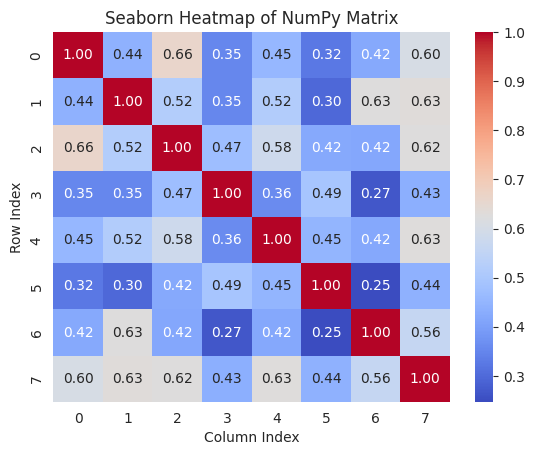

In [37]:
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap='coolwarm') # annot=True to show values, fmt for formatting
plt.title('Seaborn Heatmap of NumPy Matrix')
plt.xlabel('Column Index')
plt.ylabel('Row Index')
plt.show()

#2.From knowledge base to vectorstore


We will now use our own dataset of documents to inform our queries. Throughout the years, I have accumluated a series of AI/Deep Learning related scientific papers that are important to the field and/are representative of my interest and domain speciality.  The documents are stored in the data and are covering roughly 4 fields:

- Natural Language Processing: applications of AI to text is a major part of Deep Learning. LLLM evolved from the NLP field. I have worked a lot on text throughout the years.
- Computer Vision: from early foundation papers that launched the AI/Deep Learning revolution applied to iamges to more recent SOTA techniques.
-  Earth Observation/Remote Sensing: imagery from earth imagery has become a major source of computer vision deep learning applications. This reflects my RS and geography background
- Weather and Climate: AI is revolutionizing modeling in AI and weather and has found many applications. This also one of my interest and background.

The selection of papers is a mix of milestone AI/Deep Learning papers (e.g. Attention is all you need or An image is worth 16 words) as well a personal selection of papers covering my own interest and expertise in NLP, Remote Sensing and Weather/Climate.

**Interesting links**

- pdf:
https://medium.com/@bpmcgough/building-an-accurate-tested-rag-pipeline-for-pdf-document-search-with-langchain-01032abbe5e1

https://medium.com/@bpmcgough/comparing-pdf-parsers-1b9f5ae24afe

- pdf to markdown

https://medium.com/@arushiagg04/building-a-knowledge-base-for-rag-a-step-by-step-guide-c3afbccf3700

https://github.com/ed-donner/llm_engineering/blob/main/week5/day2.ipynb

- RAG example

https://github.com/ed-donner/llm_engineering/blob/main/week5/day2.ipynb

https://vijaykumarkartha.medium.com/beginners-guide-to-retrieval-chain-from-langchain-f307b1a20e77




## 2.1 Extracting text from pdf

In [38]:
import glob
list_files = glob.glob(os.path.join(in_dir,'*.pdf'))
print(list_files[0])
print(f'There are {len(list_files)} documents/papers.')
print('\n')
print(f'This is the paper related to BERT: \n {list_files[10]}')


/content/gdrive/MyDrive/Colab Notebooks/Large-Language-Models-applications/llm-rag-embeddings/data/MAXviT.pdf
There are 62 documents/papers.


This is the paper related to BERT: 
 /content/gdrive/MyDrive/Colab Notebooks/Large-Language-Models-applications/llm-rag-embeddings/data/modern_BERT_paper.pdf


In [39]:
from pdfminer.high_level import extract_text

pdf_name = list_files[10]

text = extract_text(os.path.join(in_dir, pdf_name))
print(text)

4
2
0
2
c
e
D
9
1

]
L
C
.
s
c
[

2
v
3
6
6
3
1
.
2
1
4
2
:
v
i
X
r
a

Smarter, Better, Faster, Longer: A Modern Bidirectional Encoder for Fast,
Memory Efficient, and Long Context Finetuning and Inference
Benjamin Warner1† Antoine Chaffin2† Benjamin Clavié1†
Orion Weller3 Oskar Hallström2 Said Taghadouini2
Alexis Gallagher1 Raja Biswas1 Faisal Ladhak4* Tom Aarsen5
Nathan Cooper1 Griffin Adams1 Jeremy Howard1 Iacopo Poli2

1Answer.AI

2LightOn 3Johns Hopkins University 4NVIDIA 5HuggingFace

†: core authors, *: work done while at Answer.AI

Correspondence: {bw,bc}@answer.ai, antoine.chaffin@lighton.ai

Abstract

Encoder-only transformer models such as
BERT offer a great performance-size tradeoff
for retrieval and classification tasks with re-
spect to larger decoder-only models. Despite
being the workhorse of numerous production
pipelines, there have been limited Pareto im-
provements to BERT since its release. In this
paper, we introduce ModernBERT, bringing
modern model optimizations t

In [40]:
#check number of tokken and words
# How many tokens in all the documents?

#model_name
print(embedding_model_name)
print(llm_model_name)
tiktoken.encoding_for_model(llm_model_name)

MODEL = llm_model_name
encoding = tiktoken.encoding_for_model(MODEL)
tokens = encoding.encode(text)
token_count = len(tokens)
print(f"Total tokens for {MODEL}: {token_count:,}")
unique_token_ids = set(tokens)
print(len(unique_token_ids))
print(len(set()))

text-embedding-3-small
gpt-3.5-turbo
Total tokens for gpt-3.5-turbo: 25,372
4589
0


So we have 94k tokens for this Llamma3 paper in our knowledge database and 10,284 unique tokens. The next after parsing the pdf is to chunk it in smaller pieces. We use the langchain text_splitter with a chunk size of 1000.

In [41]:

from langchain_text_splitters import CharacterTextSplitter

text_splitter = CharacterTextSplitter(
    separator="\n",
    chunk_size=1000,
    chunk_overlap=100
)

chunks = text_splitter.split_text(text)

for chunk in chunks[1:5]:
    print(len(chunk))
    print(chunk)
    print()

986
provements to BERT since its release. In this
paper, we introduce ModernBERT, bringing
modern model optimizations to encoder-only
models and representing a major Pareto im-
provement over older encoders. Trained on
2 trillion tokens with a native 8192 sequence
length, ModernBERT models exhibit state-of-
the-art results on a large pool of evaluations
encompassing diverse classification tasks and
both single and multi-vector retrieval on dif-
ferent domains (including code). In addition
to strong downstream performance, Modern-
BERT is also the most speed and memory effi-
cient encoder and is designed for inference on
common GPUs.
1
Introduction
After the release of BERT (Devlin et al., 2019),
encoder-only transformer-based (Vaswani et al.,
2017) language models dominated most appli-
cations of modern Natural Language Processing
(NLP). Despite the rising popularity of Large Lan-
guage Models (LLMs) such as GPT (Radford et al.,
2018, 2019; Brown et al., 2020), Llama (Touvron

995
guag

## 2.2 Loading documents in vector databasee

In [42]:
#show creation of vector store
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
vector_store = Chroma(
        embedding_function=embeddings,
        persist_directory="."
)
vector_store.add_texts(texts=chunks)
#vector_store.persist()


/tmp/ipython-input-2681643475.py:3: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vector_store = Chroma(


['30ac0ab7-58a4-460c-b632-a3f2cb218722',
 '8fec7815-55c0-4a51-8923-bb2ae6abf90f',
 '7d8318e2-d7d5-4222-848f-d3a9df0c909f',
 '458e0e8f-18c1-494a-b69a-72a5bc01068b',
 '1ae9cd21-bfec-4138-a362-5ef262923c08',
 'ca6c6148-d519-46ec-8cdf-79ed5fbd7b38',
 '480080af-2f88-47a4-ae99-0f269de101c2',
 'b182af13-6fee-496d-865e-6a08b1b00be3',
 'c5f65bce-8323-4392-8d61-417e6100e342',
 'cd4566cf-e238-454d-99b0-c199f324cd5f',
 '9562a202-6ee1-43c8-8576-e7d768f79cd6',
 '7892e6fc-d0ac-4213-a64e-f83f2d40cefd',
 '1b41d1c7-a7d5-4f90-882f-24e23697f2f1',
 'ae57879a-9428-4f29-b9e8-9b33237a23c5',
 '73737a03-d137-4885-9205-3be2d20f7813',
 'b605d28b-27f8-497d-84db-edfd4359c96a',
 '4343f4a1-5d32-422a-be7e-bbe82e20bf16',
 'a18ceb5f-1d07-49e2-88da-ba6cdbb53bfd',
 '8cadeb44-d08b-4886-ab8b-2e93b14b30e9',
 '4fddb43d-12da-474d-a6f2-84553dbc05ed',
 'c65e139a-7e24-4efd-b9bb-b5844763f8d1',
 'c35554d4-809a-44b4-a6c2-43516f0b5151',
 '794b2730-25f0-4ed5-abd8-eba86bcf9fdf',
 '66d95211-8af8-4103-8c52-02e4b6cc0b1b',
 '15c77c04-00d0-

In [43]:
!ls -ltra

total 1828
drwx------ 3 root root    4096 Feb 24 02:13 chroma_db
-rw------- 1 root root 1863680 Feb 24 02:22 chroma.sqlite3
drwx------ 2 root root    4096 Feb 24 02:22 4720206c-f4dc-427f-b4db-2d432504e76a


In [44]:
#Use all functions to load data
from langchain_text_splitters import CharacterTextSplitter
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI

#create a store
def vectorstore_creation(db_dir,model_name:str="text-embedding-3-small"):

  """
  Creating vector store
  """
  embeddings = OpenAIEmbeddings(model=model_name)
  vector_store = Chroma(
        embedding_function=embeddings,
        persist_directory=db_dir
  )
  return embeddings, vector_store

#load chunk and
def load_and_chunk(in_file:str,vector_store):
  text = extract_text(in_file)
  splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
  chunks = splitter.split_text(text)

  vector_store.add_texts(texts=chunks)

  return print(f"file added :{in_file}")



In [45]:
list_files[0:2]

['/content/gdrive/MyDrive/Colab Notebooks/Large-Language-Models-applications/llm-rag-embeddings/data/MAXviT.pdf',
 '/content/gdrive/MyDrive/Colab Notebooks/Large-Language-Models-applications/llm-rag-embeddings/data/aurora_foundation_model_earth_system_science.pdf']

Loading the text takes about 2 minutes.

In [46]:

#vector_store.add_texts(texts=chunks, metadatas=metadata_list)
db_dir= 'vector_db2'
os.makedirs(db_dir, exist_ok=True)
#vecotr_db2 = "vector_db2"
embeddings, vector_store = vectorstore_creation(db_dir=db_dir,
                                                model_name="text-embedding-3-small")
for file in list_files[0:10]:
  in_file = file
  text = extract_text(in_file)
  splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=100)
  chunks = splitter.split_text(text)

  vector_store.add_texts(texts=chunks)

  #load_and_chunkfile(file,vector_store)
  #vector_store.persist()



In [47]:
!ls -ltra
!ls -ltra ./vector_db2

total 1832
drwx------ 3 root root    4096 Feb 24 02:13 chroma_db
-rw------- 1 root root 1863680 Feb 24 02:22 chroma.sqlite3
drwx------ 2 root root    4096 Feb 24 02:22 4720206c-f4dc-427f-b4db-2d432504e76a
drwx------ 3 root root    4096 Feb 24 02:25 vector_db2
total 16596
drwx------ 2 root root     4096 Feb 24 02:24 df88586e-e902-48f9-8162-3a6e2f673fd2
-rw------- 1 root root 16990208 Feb 24 02:25 chroma.sqlite3


#3.RAG Implementation

There are multiple ways to implement RAG.

In [48]:
retriever = vector_store.as_retriever()
#llm = ChatOpenAI(temperature=0, model_name=MODEL)

In [49]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser

# 1. Define the LLM
llm = ChatOpenAI(model_name="gpt-3.5-turbo", temperature=0)

# 2. Define the RAG Prompt Template
rag_prompt = ChatPromptTemplate.from_template("""
Answer the question based ONLY on the following context:
{context}
Question: {question}
""")

# 3. Build the RAG Chain using LangChain Expression Language (LCEL)
rag_chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | rag_prompt
    | llm
    | StrOutputParser()
)

# 4. Invoke the chain
question = "What is the difference between LLM and VLM?"
response = rag_chain.invoke(question)
print(response)


The difference between LLM (Large Language Models) and VLM (Vision-Language Models) is that LLM focuses on language processing, while VLM extends LLM to incorporate visual information, such as images or visual features, in addition to text.


In [50]:
# 4. Invoke the chain
question = "Explain what attention is"
response = rag_chain.invoke(question)
print(response)

Attention is an attention mechanism that relates different positions of a single sequence in order to compute a representation of the sequence. It has been used successfully in various tasks such as reading comprehension, abstractive summarization, textual entailment, and learning task-independent sentence representations. Attention allows for the integration of information across the input sequence without relying on sequence-aligned recurrent neural networks or convolution.


In [52]:
# 4. Invoke the chain
question = "Tell me about attention applied to text and images as well as where and when it was first published."
response = rag_chain.invoke(question)
print(response)

Attention applied to text and images was first introduced in the paper "Attention is all you need" by Ashish Vaswani, Noam Shazeer, Niki Parmar, Jakob Uszkoreit, Llion Jones, Aidan N Gomez, Łukasz Kaiser, and Illia Polosukhin. This paper was published in the Advances in Neural Information Processing Systems, volume 30 in 2017.


#4.Conclusions

In this exercise, we showed how to create a RAG application to explore our own pdf AI paper documents. We explore different concepts along the way:

- embeddings

- vectorstore

- semantic search

- chat template

- chain





#5.References


LLM in production.

- LLMs in Production Engineering AI Applications By Christopher Brousseau Matt Sharp

AI Engineering.

- Huyen, Chip. 2025. AI Engineering: Building Applications with Foundation Models. Sebastopol, CA: O’Reilly Media. ISBN 978-1098166304.

Langchain

- Oshin, Mayo, and Nuno Campos. 2025. Learning LangChain: Building AI and LLM Applications with LangChain and LangGraph. Sebastopol, CA: O’Reilly Media. ISBN 978-1098167288.


In [ ]:
############################# END OF SCRIPT ###################################